<a href="https://colab.research.google.com/github/sharvmahajan/TE/blob/DSBDAL/A2/DSBDAL_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DSBDAL Assignment 2
Name: Sharv Mahajan

Roll No.: 31430

In [ ]:
import pandas as pd
import numpy as np

###Loading Dataset

[Dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')

###Initial Survey

In [ ]:
display(df.head())
df.describe()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


###Inconsistent Score Checking

In [ ]:
print("Math Score: ", len(df[(df["math score"] < 0) | (df["math score"] > 100)]))
print("Reading Score: ", len(df[(df["reading score"] < 0) | (df["reading score"] > 100)]))
print("Writing Score: ", len(df[(df["writing score"] < 0) | (df["writing score"] > 100)]))

Math Score:  0
Reading Score:  0
Writing Score:  0


###Missing Value
Since there are no missing values, we will be creating missing values

In [ ]:
np.random.seed(42)
random_rows = np.random.choice(df.index, size=10, replace=False)

df.loc[random_rows, "math score"] = np.nan
df.loc[random_rows, "reading score"] = np.nan

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,10
reading score,10
writing score,0


###Filling missing values
First we will check skewness.
If distribution is skewed then we will prefer median, otherwise we will prefer mean.


In [ ]:
print("Math skew:", df['math score'].skew())
print("Reading skew:", df['reading score'].skew())
print("Writing skew:", df['writing score'].skew())

Math skew: -0.27789448596244004
Reading skew: -0.255345985186791
Writing skew: -0.28944397150761897


Distribution is not skewed, [abs(Skew) < 0.5]. Hence, fill  with mean values.

In [ ]:
df["math score"] = df["math score"].fillna(df["math score"].mean())
df["reading score"] = df["reading score"].fillna(df["reading score"].mean())

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## Outlier Detection

1) Z-Score
*   abs(Z-Score) > 3

2) IQR (Q3 - Q1)
*   lower_bound = Q1 - 1.5 * IQR
*   upper_bound = Q3 + 1.5 * IQR


In [ ]:
numerical_cols = ['math score', 'reading score', 'writing score']

for col in numerical_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()

    df[f'{col}_zscore'] = (df[col] - mean_val) / std_val

    # Outliers (absolute Z-score > 3)
    outliers = df[df[f'{col}_zscore'].abs() > 3]

    print(f"Number of outliers in '{col}': {len(outliers)}")

Number of outliers in 'math score': 4
Number of outliers in 'reading score': 4
Number of outliers in 'writing score': 4


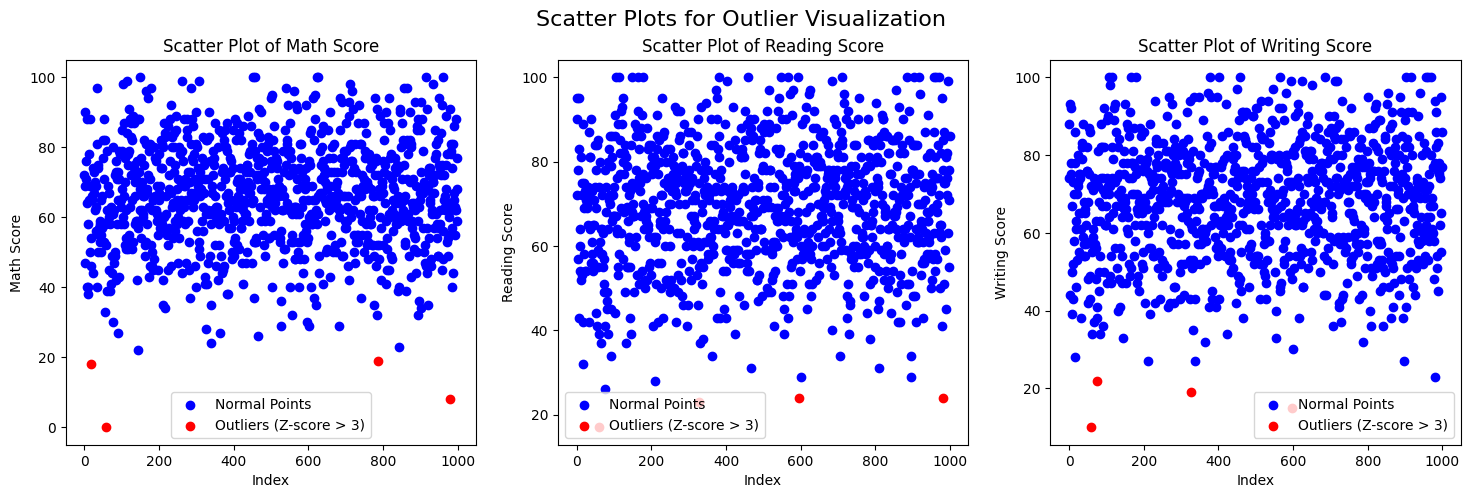

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter Plots for Outlier Visualization', fontsize=16)

numerical_cols = ['math score', 'reading score', 'writing score']

for i, col in enumerate(numerical_cols):
    # Identify outliers using the Z-score (already calculated)
    outliers_mask = df[f'{col}_zscore'].abs() > 3

    # Plot non-outliers
    axes[i].scatter(df.index[~outliers_mask], df[col][~outliers_mask], label='Normal Points', color='blue')
    # Plot outliers in a different color
    axes[i].scatter(df.index[outliers_mask], df[col][outliers_mask], label='Outliers (Z-score > 3)', color='red')

    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(col.replace('_', ' ').title())
    axes[i].set_title(f'Scatter Plot of {col.replace('_', ' ').title()}')
    axes[i].legend()

plt.show()

In [ ]:
numerical_cols = ['math score', 'reading score', 'writing score']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Number of outliers in '{col}' (IQR method): {len(outliers_iqr)}")

Number of outliers in 'math score' (IQR method): 11
Number of outliers in 'reading score' (IQR method): 6
Number of outliers in 'writing score' (IQR method): 5


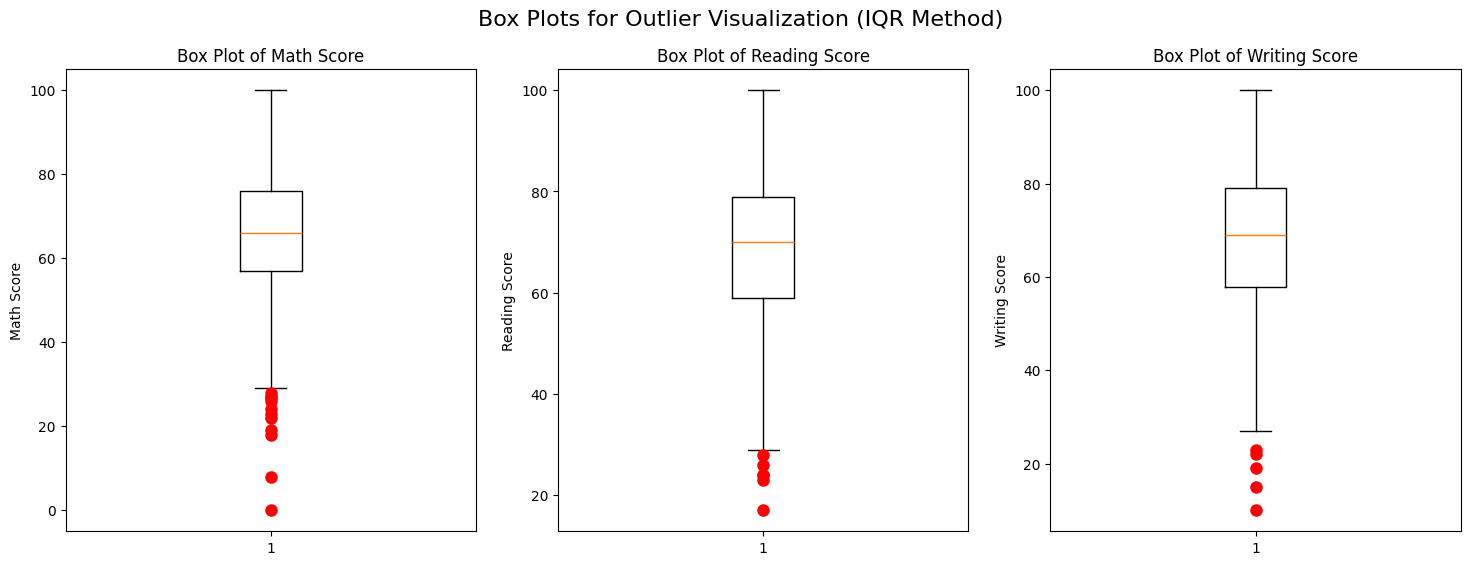

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots for Outlier Visualization (IQR Method)', fontsize=16)

numerical_cols = ['math score', 'reading score', 'writing score']

# Define flier properties for outliers (red circles)
flierprops = dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none', markeredgecolor='red')

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], flierprops=flierprops)
    axes[i].set_ylabel(col.replace('_', ' ').title())
    axes[i].set_title(f'Box Plot of {col.replace('_', ' ').title()}')

plt.show()

###Removing Outliers
Removing outliers by IQR capping.

In [ ]:
for col in ["math score", "reading score", "writing score"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


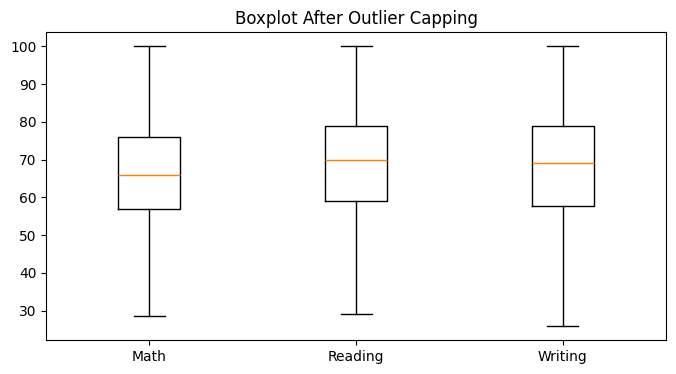

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(
    [df["math score"], df["reading score"], df["writing score"]],
    tick_labels=["Math", "Reading", "Writing"]
)
plt.title("Boxplot After Outlier Capping")
plt.show()

In [ ]:
df.describe()

,math score,reading score,writing score,math score_zscore,reading score_zscore,writing score_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,66.116753,69.174424,68.094375,-5.861978e-17,-8.668621e-16,-1.314504e-16
std,14.801392,14.472188,15.068368,1.000000e+00,1.000000e+00,1.000000e+00
min,28.500000,29.000000,25.875000,-4.377414e+00,-3.578986e+00,-3.820434e+00
25%,57.000000,59.000000,57.750000,-5.983660e-01,-6.961624e-01,-6.780885e-01
50%,66.000000,70.000000,69.000000,-1.674219e-03,5.886285e-02,6.225463e-02
75%,76.000000,79.000000,79.000000,6.613166e-01,6.766108e-01,7.203374e-01
max,100.000000,100.000000,100.000000,2.252495e+00,2.118023e+00,2.102311e+00


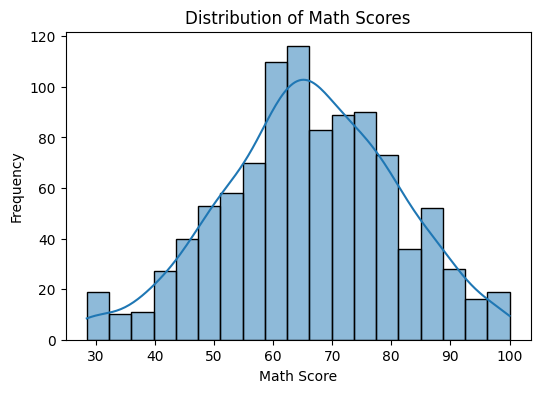

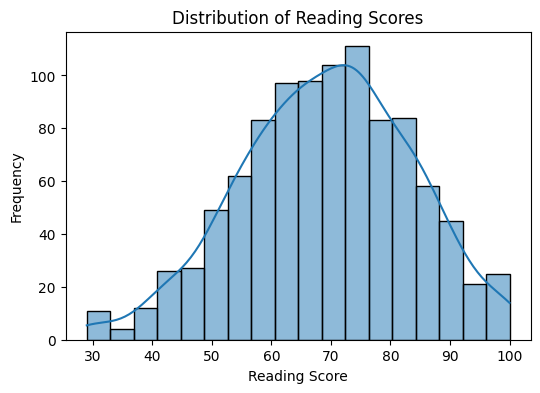

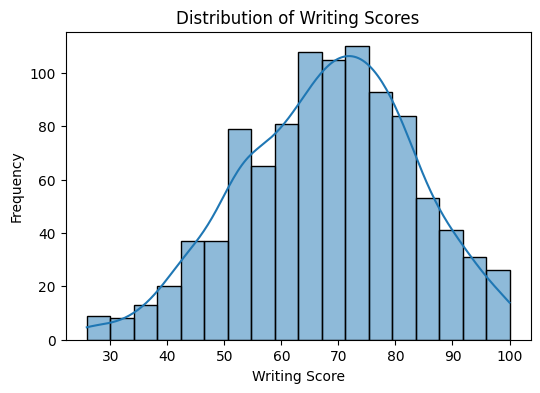

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["math score"], kde=True)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df["reading score"], kde=True)
plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df["writing score"], kde=True)
plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")
plt.ylabel("Frequency")
plt.show()


Math score is slightly skewed to left. Lets use z-score scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["math_score_std", "reading_score_std", "writing_score_std"]] = scaler.fit_transform(
    df[["math score", "reading score", "writing score"]]
)

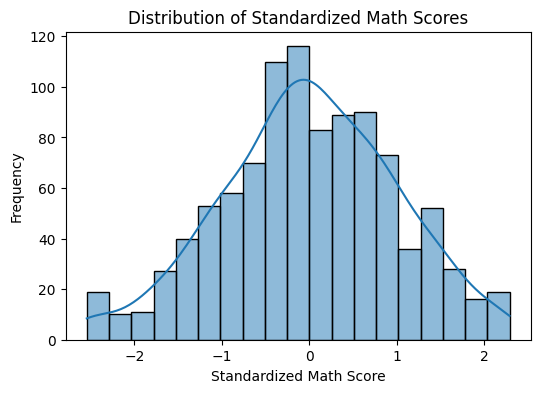

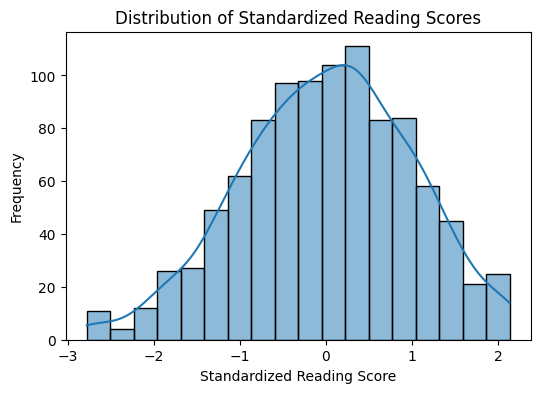

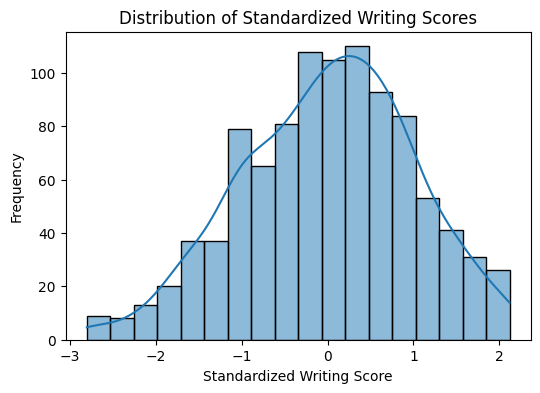

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["math_score_std"], kde=True)
plt.title("Distribution of Standardized Math Scores")
plt.xlabel("Standardized Math Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df["reading_score_std"], kde=True)
plt.title("Distribution of Standardized Reading Scores")
plt.xlabel("Standardized Reading Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df["writing_score_std"], kde=True)
plt.title("Distribution of Standardized Writing Scores")
plt.xlabel("Standardized Writing Score")
plt.ylabel("Frequency")
plt.show()